# **1. 라이브러리 Import**

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


# 재현성을 위한 seed 설정
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [14]:
# 데이터 로드
df = pd.read_csv('../../data/processed/cleaned_disease_dataset_2015landuse.csv')

print(f"Total samples: {len(df):,}")
df.head()


# 컬럼 분류
key_cols = ['year', 'country', 'admin']
#target_col = 'infection_rate'
target_col = 'infection_risk_level'
climate_cols = ['max_temperature', 'min_temperature', 'avg_temperature']
livestock_cols = ['Buffa', 'Cattl', 'Chick', 'Ducks', 'Goats', 'Horse', 'Sheep', 'Swine']
landuse_cols = ['rate_landuse']
feature_cols = climate_cols + livestock_cols + landuse_cols

print(f"Feature 컬럼 ({len(feature_cols)}개): {feature_cols}")
print(f"Target 컬럼: {target_col}")

Total samples: 473
Feature 컬럼 (12개): ['max_temperature', 'min_temperature', 'avg_temperature', 'Buffa', 'Cattl', 'Chick', 'Ducks', 'Goats', 'Horse', 'Sheep', 'Swine', 'rate_landuse']
Target 컬럼: infection_risk_level


In [15]:
#자연발생 클러스터링
from jenkspy import JenksNaturalBreaks

df.columns

i = 3

breaks = JenksNaturalBreaks(n_classes=i)
breaks.fit(df["infection_rate"])
print(breaks.breaks_)  # 구간 경계

df["infection_risk_level"] = pd.cut(
    df["infection_rate"], bins=breaks.breaks_, labels=range(i), include_lowest=True
)
df["infection_risk_level"].value_counts()

[0.0, 6.027164685908319, 15.030674846625766, 27.07340324118208]


infection_risk_level
0    340
1     75
2     58
Name: count, dtype: int64

In [8]:
# KMeans 기반 클러스터링

from sklearn.cluster import KMeans

k = 4

X = df["infection_rate"].values.reshape(-1, 1)

kmeans = KMeans(n_clusters=k, random_state=0)
clusters = kmeans.fit_predict(X)

centers = kmeans.cluster_centers_.flatten()
sorted_idx = np.argsort(centers)
label_map = {old: new for new, old in enumerate(sorted_idx)}
sorted_labels = np.vectorize(label_map.get)(clusters)

df["infection_risk_level"] = sorted_labels

df["infection_risk_level"].value_counts().sort_index()

infection_risk_level
0    305
1     74
2     57
3     37
Name: count, dtype: int64

In [4]:
# X, y 분리
X = df[feature_cols].copy()
y = df[target_col].copy()

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")


# train, test dataset 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("=== Random Split ===")
print(f"Train set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
# print(f"\nTrain - y 평균: {y_train.mean():.4f}, 표준편차: {y_train.std():.4f}")
# print(f"Test - y 평균: {y_test.mean():.4f}, 표준편차: {y_test.std():.4f}")

X shape: (473, 12)
y shape: (473,)
=== Random Split ===
Train set: 378 samples (79.9%)
Test set: 95 samples (20.1%)


In [5]:
#  랜덤포레스트 
rf = RandomForestClassifier(random_state = 0)
rf.fit(X_train, y_train)
pred = rf.predict(X_test)
accuracy = accuracy_score(y_test, pred)
print('자연발생 클러스터링 기반 랜덤 포레스트 정확도: {:.4f}'.format(accuracy))

자연발생 클러스터링 기반 랜덤 포레스트 정확도: 0.8316


In [10]:
# K-means  랜덤포레스트 
rf = RandomForestClassifier(random_state = 0)
rf.fit(X_train, y_train)
pred = rf.predict(X_test)
accuracy = accuracy_score(y_test, pred)
print('K-means 클러스터링 기반 랜덤 포레스트 정확도: {:.4f}'.format(accuracy))

K-means 클러스터링 기반 랜덤 포레스트 정확도: 0.8105


In [6]:
# Accuracy 분석

from sklearn.metrics import classification_report, accuracy_score

print("Complaint Level (Kmeans) Classification Accuracy:", round(accuracy_score(y_test, pred), 3))
print(classification_report(y_test, pred, target_names=['Low', 'Mid', 'High']))

Complaint Level (Kmeans) Classification Accuracy: 0.832
              precision    recall  f1-score   support

         Low       0.87      0.97      0.92        67
         Mid       0.67      0.40      0.50        20
        High       0.75      0.75      0.75         8

    accuracy                           0.83        95
   macro avg       0.76      0.71      0.72        95
weighted avg       0.81      0.83      0.81        95



count of each level in train data


infection_risk_level
0    273
1     55
2     50
Name: count, dtype: int64

count of each level in test data


infection_risk_level
0    67
1    20
2     8
Name: count, dtype: int64

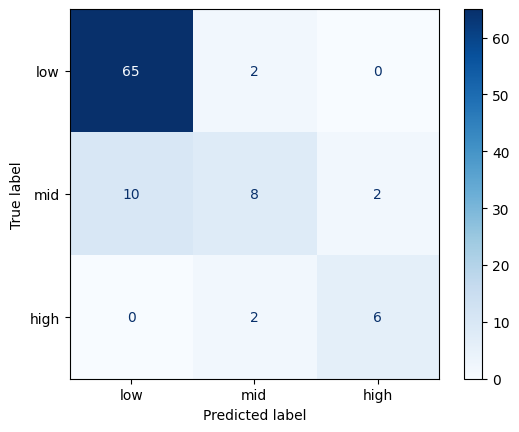

In [7]:
# low class accuracy 분석
# 다른 level에 비해 정확도가 높은 이유는?

# 가정1) 데이터 자체가 많다.

import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# (1) level 별로 train/test data에서 개수 확인
print("count of each level in train data")
display(pd.Series(y_train).value_counts())
print("count of each level in test data")
display(pd.Series(y_test).value_counts())

# (2) rf 모델에서 class_weight="balanced" 인자 설정에 따른 성능 차이 확인하기 -> 차이 없음 -> 데이터 불균형의 영향 적음
cm = confusion_matrix(y_test, pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["low", "mid", "high"])
disp.plot(cmap="Blues")

In [10]:
# 교차 검증
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(rf, X, y, cv=skf, scoring='f1_macro')
print(f"평균 F1 Score: {scores.mean():.4f}")

평균 F1 Score: 0.7932


결과 분석 및 성능 향상 실험

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# class_weight='balanced' 또는 'balanced_subsample' 옵션 사용
# 'balanced': 전체 데이터 비율의 역수로 가중치 자동 부여
# 'balanced_subsample': 각 트리를 만들 때 샘플링된 데이터 기준으로 가중치 부여 (더 정교함)
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced_subsample', # 핵심!
    random_state=42
)
rf.fit(X_train, y_train)
pred = rf.predict(X_test)
accuracy = accuracy_score(y_test, pred)

print("Complaint Level (Kmeans) Classification Accuracy:", round(accuracy_score(y_test, pred), 3))
print(classification_report(y_test, pred, target_names=['Low', 'Mid', 'High']))

Complaint Level (Kmeans) Classification Accuracy: 0.832
              precision    recall  f1-score   support

         Low       0.87      0.97      0.92        67
         Mid       0.67      0.40      0.50        20
        High       0.75      0.75      0.75         8

    accuracy                           0.83        95
   macro avg       0.76      0.71      0.72        95
weighted avg       0.81      0.83      0.81        95



데이터 개수에 따른 가중치를 주어도 변함이 없음

왜 변화가 없을까요? (가능한 이유 3가지)
- 이유 1: 결정 경계가 너무 "단단"합니다.
    - class_weight는 소수 클래스(High/Mid)를 틀렸을 때 벌점(Loss)을 더 많이 주는 방식입니다.
    - 하지만 모델이 보기에 "벌점을 아무리 많이 받아도, 도저히 여기엔 선을 못 긋겠다" 싶을 정도로 Low와 Mid/High 데이터가 피처(Feature) 상에서 완전히 겹쳐 있을(Overlap) 가능성이 큽니다. 벌점을 감수하고서라도 그냥 Low라고 찍는 게 낫다고 판단한 것이죠.

- 이유 2: 테스트 데이터가 "애매"합니다.
    - Train 데이터에서는 가중치 덕분에 학습이 조금 달라졌을 수 있습니다.
    - 하지만 막상 Test 데이터에 있는 샘플들이 결정 경계에서 아주 멀리 떨어져 있어서(확실한 Low거나 확실한 High가 아니어서), 경계가 조금 움직인 정도로는 예측 결과(Label)가 뒤집히지 않았을 수 있습니다.

- 이유 3: 기본 balanced 가중치가 약합니다.
    - balanced 옵션은 데이터 비율의 역수만큼 가중치를 줍니다. (예: Low가 Mid보다 3배 많으면, Mid에 가중치 3배)
    - 하지만 데이터가 470개로 적을 때는 3배 정도로는 부족할 수 있습니다. 10배, 20배 더 강력한 충격을 줘야 모델이 움직일 수 있습니다.

단순 가중치 말고 데이터 자체를 증강시켜서 돌려보기

In [19]:
!pip install imbalanced-learn

In [20]:
from imblearn.over_sampling import SMOTE

# 1. 가짜 데이터를 생성해서 Mid, High 개수를 Low만큼 뻥튀기합니다.
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# 2. 뻥튀기된 데이터로 학습 (가중치 옵션 없이도 데이터가 많아서 잘 배움)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_resampled, y_train_resampled) # resampled 데이터 사용!

# 3. 평가
pred = rf.predict(X_test)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.90      0.99      0.94        67
           1       0.77      0.50      0.61        20
           2       0.67      0.75      0.71         8

    accuracy                           0.86        95
   macro avg       0.78      0.75      0.75        95
weighted avg       0.86      0.86      0.85        95



정리

1. 발병률 회귀보단 자연발생 클러스터링을 통한 위험도를 새롭게 output으로 설정하는 것이 나음
2. 클래스 별 metric을 확인해봤을 때, mid class에 대한 성능이 좋지 않음
3. mid 클래스 자체가 데이터 개수가 적으므로 가중치로 보정해봐도 성능이 달라지지 않음
4. SMOTE 기법을 통해 클래스별 데이터 개수를 맞추고(부족한 클래스는 뻥튀기!!) 다시 진행해보면 정확도가 훨씬 나아짐
    - 근데 class 0(row)의 정확도가 1에 너어어무 가까움
    - mid의 정확도가 계속 낮은 걸로 보아 mid,high 에서 애매한 건 전부 Low로 보내고 있을 가능성도 고려